# Week 3: Statistics & Probability

## AnalystLab Africa Data Science Internship

### Introduction

Statistics and probability form the foundation of data science. Before building predictive models, it is important to understand the characteristics of the data through statistical analysis.

This notebook explores statistical concepts using the cleaned Titanic and Housing datasets prepared during Week 1–2 of the internship.

The analysis focuses on:

- Descriptive statistics
- Probability distributions
- Hypothesis testing
- Correlation vs causation

The insights gained from this analysis will support future machine learning tasks.

In [2]:
# Importing Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
%matplotlib inline 
sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)



# Load the Cleaned Datasets

The cleaned datasets produced during Week 1–2 are loaded into the notebook for statistical analysis.

Using the cleaned datasets ensures that the statistical results are not affected by duplicate records or unnecessary missing values.

In [3]:
# Loading the cleaned datasets from week 1-2

try:
    print("Loading the cleaned datasets")
    # Load the cleaned Titanic dataset
    titanic = pd.read_csv("../../datasets/processed/Titanic_Cleaned.csv")

    # Load the cleaned Housing dataset
    housing = pd.read_csv("../../datasets/processed/Housing_Cleaned.csv")

    print("Datasets loaded successfully!")

except Exception as e:
    print(f"An error occured: {e}")

Loading the cleaned datasets
Datasets loaded successfully!


In [4]:
# Displaying dataset information

# Information about the titanic dataset
print("TITANIC DATASET")
display(titanic.head())
print("\nShape:", titanic.shape)

# Information about the housing dataset
print("HOUSING DATASET")
display(housing.head())
print("\nShape:", housing.shape)

TITANIC DATASET


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S



Shape: (891, 11)
HOUSING DATASET


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished



Shape: (545, 13)


# Descriptive Statistics

Descriptive statistics summarise the main characteristics of a dataset.

They help us understand the distribution, spread, and central tendency of numerical variables.

The following statistics will be calculated:

- Mean
- Median
- Mode
- Minimum
- Maximum
- Range
- Variance
- Standard Deviation
- Quartiles
- Interquartile Range (IQR)

In [5]:
# Calculations of descriptive statistics
# Generating descriptive statistics for all numerical columns.
def descriptive_statistics(df):
    
    # Select numerical columns only
    numerical_df = df.select_dtypes(include=np.number)

    # Create an empty dictionary
    statistics = {}

    # Calculate statistics for each numerical column
    for column in numerical_df.columns:

        statistics[column] = {
            "Mean": numerical_df[column].mean(),
            "Median": numerical_df[column].median(),
            "Mode": numerical_df[column].mode()[0],
            "Minimum": numerical_df[column].min(),
            "Maximum": numerical_df[column].max(),
            "Range": numerical_df[column].max() - numerical_df[column].min(),
            "Variance": numerical_df[column].var(),
            "Standard Deviation": numerical_df[column].std(),
            "Q1": numerical_df[column].quantile(0.25),
            "Q3": numerical_df[column].quantile(0.75),
            "IQR": numerical_df[column].quantile(0.75) - numerical_df[column].quantile(0.25)
        }

    return pd.DataFrame(statistics).T

In [6]:
# Descriptive statistics for the titanic dataset
print("DESCRIPTIVE STATISTICS - TITANIC DATASET")
display(descriptive_statistics(titanic))

DESCRIPTIVE STATISTICS - TITANIC DATASET


,Mean,Median,Mode,Minimum,Maximum,Range,Variance,Standard Deviation,Q1,Q3,IQR
PassengerId,446.000000,446.0000,1.00,1.00,891.0000,890.0000,66231.000000,257.353842,223.5000,668.5,445.0000
Survived,0.383838,0.0000,0.00,0.00,1.0000,1.0000,0.236772,0.486592,0.0000,1.0,1.0000
Pclass,2.308642,3.0000,3.00,1.00,3.0000,2.0000,0.699015,0.836071,2.0000,3.0,1.0000
Age,29.361582,28.0000,28.00,0.42,80.0000,79.5800,169.512498,13.019697,22.0000,35.0,13.0000
SibSp,0.523008,0.0000,0.00,0.00,8.0000,8.0000,1.216043,1.102743,0.0000,1.0,1.0000
Parch,0.381594,0.0000,0.00,0.00,6.0000,6.0000,0.649728,0.806057,0.0000,0.0,0.0000
Fare,32.204208,14.4542,8.05,0.00,512.3292,512.3292,2469.436846,49.693429,7.9104,31.0,23.0896


In [7]:
# Descriptive statistics for the housing dataset
print("DESCRIPTIVE STATISTICS - HOUSING DATASET")
display(descriptive_statistics(housing))

DESCRIPTIVE STATISTICS - HOUSING DATASET


,Mean,Median,Mode,Minimum,Maximum,Range,Variance,Standard Deviation,Q1,Q3,IQR
price,4.766729e+06,4340000.0,3500000.0,1750000.0,13300000.0,11550000.0,3.498544e+12,1.870440e+06,3430000.0,5740000.0,2310000.0
area,5.150541e+03,4600.0,6000.0,1650.0,16200.0,14550.0,4.709512e+06,2.170141e+03,3600.0,6360.0,2760.0
bedrooms,2.965138e+00,3.0,3.0,1.0,6.0,5.0,5.447383e-01,7.380639e-01,2.0,3.0,1.0
bathrooms,1.286239e+00,1.0,1.0,1.0,4.0,3.0,2.524757e-01,5.024696e-01,1.0,2.0,1.0
stories,1.805505e+00,2.0,2.0,1.0,4.0,3.0,7.525432e-01,8.674925e-01,1.0,2.0,1.0
parking,6.935780e-01,0.0,0.0,0.0,3.0,3.0,7.423300e-01,8.615858e-01,0.0,1.0,1.0


## Interpretation

The mean and median show the typical values for each feature, while the variance and standard deviation measure how spread out the data is.

The interquartile range (IQR) helps identify the spread of the middle 50% of the data and can be useful for detecting potential outliers.

These statistics provide a foundation for understanding the datasets before exploring probability distributions and hypothesis testing.

# Probability Distributions

A probability distribution describes how the values of a variable are spread across a dataset.

Understanding the distribution of data helps determine whether a variable follows a normal distribution, is skewed, or contains outliers.

For this analysis, the following numerical variables will be explored:

## Titanic Dataset
- Age
- Fare

## Housing Dataset
- Price
- Area

These variables are chosen because they have a high range. For each variable, the following visualisations will be created:

- Histogram
- Density (KDE) Plot
- Box Plot

These visualisations will help identify the shape of the distribution and detect possible outliers.

In [8]:
# A function to visualise a distribution
"""This function will plot a histogram with a Density Plot(KDE),
and a box and wiskers diagram to easier understand the spread 
and skewness of the data  """
def plot_distribution(df, column):
    
    plt.figure(figsize=(10,6))

    # Ploting histogram with KDE
    sns.histplot(
        data=df,
        x=column,
        kde=True,
        bins=30
    )

    # Add title and labels
    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Frequency")

    plt.show()

    # Create box plot
    plt.figure(figsize=(10,2))

    sns.boxplot(
        x=df[column]
    )

    plt.title(f"Box Plot of {column}")

    plt.show()

# Titanic Dataset visualizations

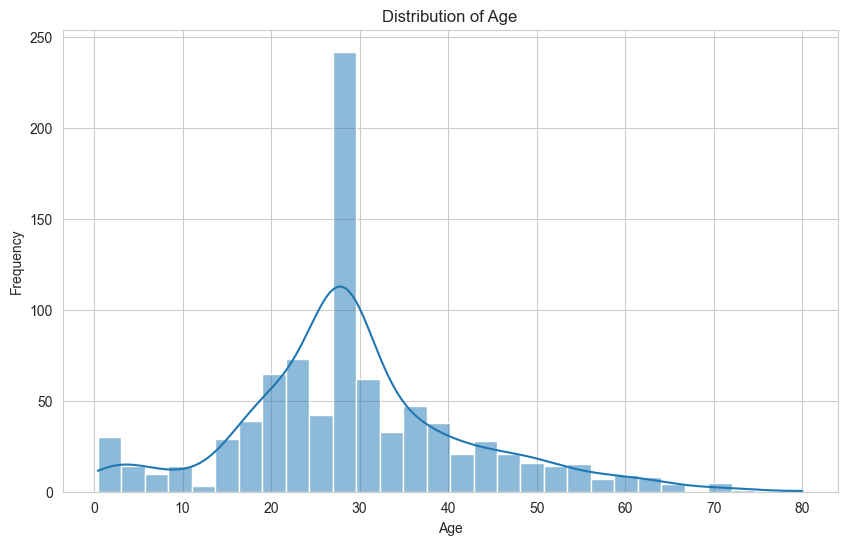

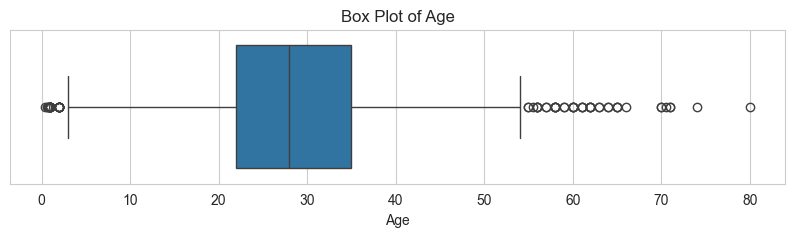

In [9]:
# Titanic age distribution
plot_distribution(titanic, "Age")

### Interpretation

The Age distribution shows the spread of passenger ages aboard the Titanic.

The histogram indicates where most passengers fall, while the KDE curve helps visualise the overall shape of the distribution.

The box plot highlights any unusually young or old passengers that may be considered outliers.

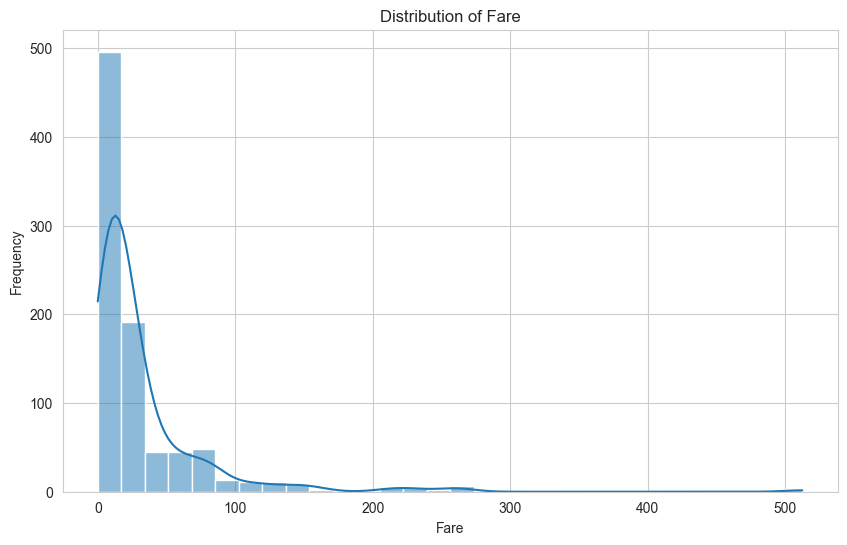

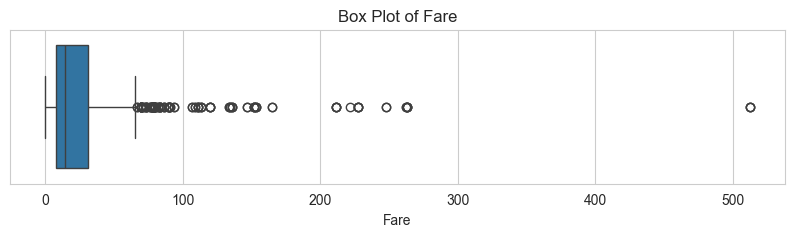

In [10]:
# titanic fare distribution

plot_distribution(titanic, "Fare")

### Interpretation

The Fare distribution illustrates the variation in ticket prices paid by passengers.

The distribution is expected to be positively skewed because a relatively small number of passengers paid substantially higher fares than the majority.

The box plot helps identify passengers with unusually expensive tickets.

# Housing Dataset visualisation

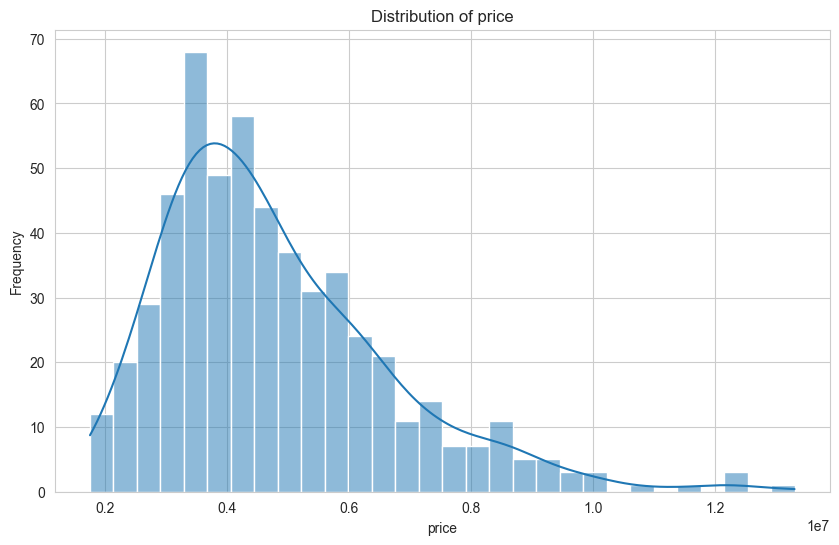

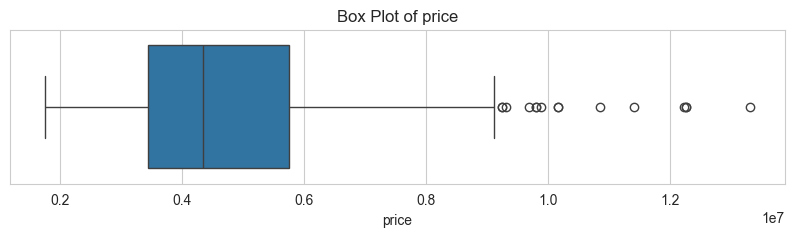

In [11]:
# House price distribution

plot_distribution(housing, "price")

### Interpretation

The selling price distribution shows how house prices are spread across the dataset.

Most houses are expected to fall within a particular price range, while a few expensive properties may appear as outliers.

The KDE curve provides a smoother representation of the overall distribution.

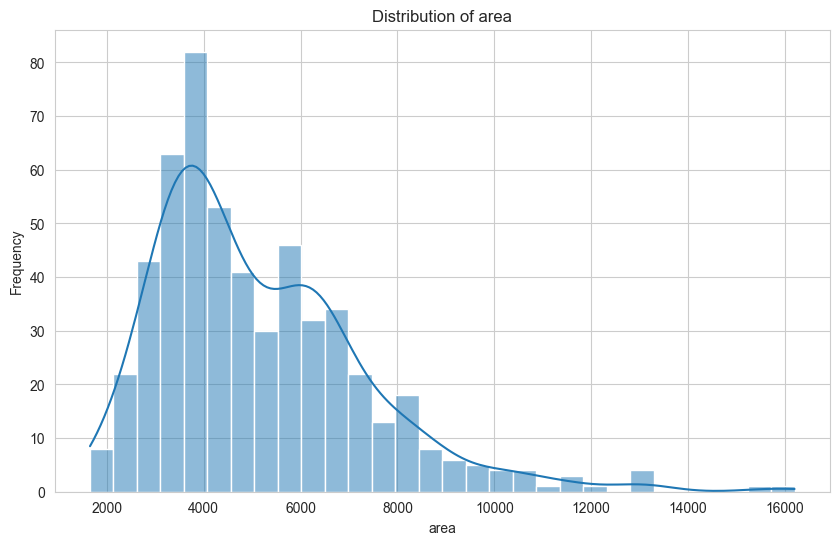

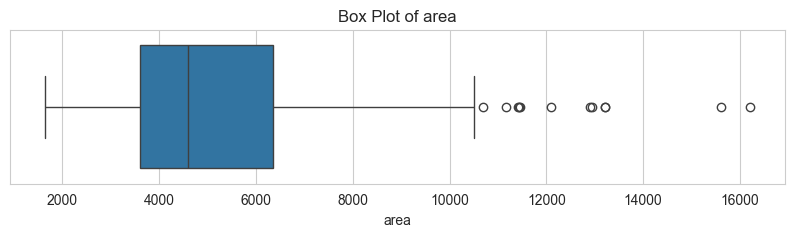

In [12]:
# Area distribution

plot_distribution(housing, "area")

### Interpretation

The distribution of property area helps us understand the variation in house sizes.

The box plot can reveal unusually small or exceptionally large properties, while the histogram shows where most observations are concentrated.

# Understanding Probability Distributions

From the visualisations above, we can observe whether each variable follows a normal distribution or is skewed.

A normal distribution is characterised by a symmetric bell-shaped curve.

A positively skewed distribution has a longer tail extending to the right, indicating a small number of unusually large values.

A negatively skewed distribution has a longer tail extending to the left, indicating a small number of unusually small values.

Understanding these distributions is important because many statistical tests assume that the data follows a normal distribution.

# Hypothesis Testing

Hypothesis testing is a statistical method used to determine whether there is enough evidence to support a claim about a population.

In this section, an Independent Samples t-test will be used to compare the means of two independent groups.

The hypothesis testing process consists of:

1. Defining the null hypothesis (H₀)
2. Defining the alternative hypothesis (H₁)
3. Selecting a significance level (α = 0.05)
4. Calculating the test statistic and p-value
5. Making a decision
6. Interpreting the results

A p-value less than 0.05 indicates that the observed difference between groups is statistically significant.

# Titanic dataset

## Hypothesis Test 1: Passenger Age and Survival

This test investigates whether the average age differs between passengers who survived and those who did not survive.

### Null Hypothesis (H₀)

There is **no significant difference** in the average age of survivors and non-survivors.

### Alternative Hypothesis (H₁)

There **is a significant difference** in the average age of survivors and non-survivors.

In [13]:
# Hypotheisis testing for the titanic dataset

# Hypothesis test 1
# Create two groups
survivors = titanic[titanic["Survived"] == 1]["Age"]
non_survivors = titanic[titanic["Survived"] == 0]["Age"]

# Perform an independent samples t-test
t_statistic, p_value = stats.ttest_ind(
    survivors,
    non_survivors,
    equal_var=False
)

print("Independent Samples t-Test")

print(f"T-statistic : {t_statistic:.4f}")
print(f"P-value     : {p_value:.4f}")

Independent Samples t-Test
T-statistic : -1.8966
P-value     : 0.0583


In [14]:
# Interpretation and drawing a conclusion
alpha_1 = 0.05

if p_value < alpha_1:
    print("Decision: Reject the Null Hypothesis")
    print("\nConclusion:")
    print("There is a statistically significant difference")
    print("between the average ages of survivors and")
    print("non-survivors.")
else:
    print("Decision: Fail to Reject the Null Hypothesis")
    print("\nConclusion:")
    print("There is no statistically significant difference")
    print("between the average ages of survivors and")
    print("non-survivors.")

Decision: Fail to Reject the Null Hypothesis

Conclusion:
There is no statistically significant difference
between the average ages of survivors and
non-survivors.


## Hypothesis Test 2: Passenger Class and Survival

This test investigates whether passenger class is associated with survival.

### Null Hypothesis (H₀)

Passenger class and survival are independent. In particular, third-class passengers did **not** have a lower survival rate than expected by chance.

### Alternative Hypothesis (H₁)

Passenger class and survival are associated. Third-class passengers had a lower survival rate compared with first- and second-class passengers.

In [15]:
# Passanger class and survival relationship

from scipy.stats import chi2_contingency
# Create a contingency table
contingency_table = pd.crosstab(titanic["Pclass"], titanic["Survived"])

print("Contingency Table")
display(contingency_table)

# Perform Chi-Square Test
chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print("Chi-Square Test Results")
print(f"Chi-square Statistic : {chi2:.4f}")
print(f"P-value              : {p_value:.4f}")
print(f"Degrees of Freedom   : {dof}")

alpha = 0.05

if p_value < alpha:
    print("\nDecision: Reject the NULL Hypothesis")
    print("Conclusion: Passenger class is significantly associated with survival.")
else:
    print("\nDecision: Fail to Reject NULL Hypothesis")
    print("Conclusion: There is no significant association between passenger class and survival.")

Contingency Table


Survived,0,1
Pclass,,
1,80,136
2,97,87
3,372,119


Chi-Square Test Results
Chi-square Statistic : 102.8890
P-value              : 0.0000
Degrees of Freedom   : 2

Decision: Reject the NULL Hypothesis
Conclusion: Passenger class is significantly associated with survival.


## Hypothesis Test 3: Female Survivors and Passenger Class

This test investigates whether female survivors were more likely to come from first class.

### Null Hypothesis (H₀)

Passenger class and female survival are independent.

### Alternative Hypothesis (H₁)

Passenger class is associated with female survival, with first-class women having higher survival rates.

In [16]:
# Checking if the females had a class advantage in term of survival

female_survivors = titanic[
    (titanic["Sex"] == "female") &
    (titanic["Survived"] == 1)
]

contingency_table = pd.crosstab(
    female_survivors["Pclass"],
    female_survivors["Survived"]
)

print("Contingency Table")
display(contingency_table)


# Chi-Square Test
chi2, p_value, dof, expected = chi2_contingency(contingency_table)


print("Chi-Square Test Results")
print(f"Chi-square Statistic : {chi2:.4f}")
print(f"P-value              : {p_value:.4f}")

alpha = 0.05

if p_value < alpha:
    print("\nDecision: Reject Null hypothesis")
    print("Conclusion: Female survival is significantly associated with passenger class.")
else:
    print("\nDecision: Fail to Reject Null hypothesis")
    print("Conclusion: There is no significant association between female survival and passenger class.")


Contingency Table


Survived,1
Pclass,
1,91
2,70
3,72


Chi-Square Test Results
Chi-square Statistic : 0.0000
P-value              : 1.0000

Decision: Fail to Reject Null hypothesis
Conclusion: There is no significant association between female survival and passenger class.


In [17]:
# Checking if the females had a class advantage in term of survival

from scipy.stats import chi2_contingency

# Filter all male passengers
male_passengers = titanic[titanic["Sex"] == "male"]

# Create contingency table
contingency_table = pd.crosstab(
    male_passengers["Pclass"],
    male_passengers["Survived"]
)

print("Contingency Table")
display(contingency_table)

# Perform Chi-Square Test
chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print("\nChi-Square Test Results")
print(f"Chi-square Statistic : {chi2:.4f}")
print(f"P-value              : {p_value:.4f}")

alpha = 0.05

if p_value < alpha:
    print("\nDecision: Reject the Null Hypothesis")
    print("Conclusion: Male survival is significantly associated with passenger class.")
else:
    print("\nDecision: Fail to Reject the Null Hypothesis")
    print("Conclusion: There is no significant association between male survival and passenger class.")

Contingency Table


Survived,0,1
Pclass,,
1,77,45
2,91,17
3,300,47



Chi-Square Test Results
Chi-square Statistic : 32.9541
P-value              : 0.0000

Decision: Reject the Null Hypothesis
Conclusion: Male survival is significantly associated with passenger class.


# Housing dataset

## Hypothesis Test 1: House Price and Preferred Area

This test investigates whether houses located in preferred residential areas have significantly different selling prices compared with houses outside preferred areas.

### Null Hypothesis (H₀)

There is **no significant difference** in average selling prices between preferred and non-preferred areas.

### Alternative Hypothesis (H₁)

There **is a significant difference** in average selling prices between preferred and non-preferred areas.

In [18]:

preferred = housing[housing["prefarea"] == "yes"]["price"]
not_preferred = housing[housing["prefarea"] == "no"]["price"]

# Perform an independent samples t-test
t_statistic, p_value = stats.ttest_ind(
    preferred,
    not_preferred,
    equal_var=False
)

print("Independent Samples t-Test")
print(f"T-statistic : {t_statistic:.4f}")
print(f"P-value     : {p_value:.4f}")

Independent Samples t-Test
T-statistic : 7.4923
P-value     : 0.0000


In [19]:

if p_value < alpha:
    print("Decision: Reject the Null Hypothesis")
    print("\nConclusion:")
    print("House prices differ significantly")
    print("between preferred and non-preferred areas.")
else:
    print("Decision: Fail to Reject the Null Hypothesis")
    print("\nConclusion:")
    print("There is no statistically significant")
    print("difference in house prices.")

Decision: Reject the Null Hypothesis

Conclusion:
House prices differ significantly
between preferred and non-preferred areas.


## Hypothesis Test 2: Does the Number of Bedrooms Affect House Prices?

This test investigates whether the average selling price differs based on the number of bedrooms.

### Null Hypothesis (H₀)

The average selling price is the same regardless of the number of bedrooms.

### Alternative Hypothesis (H₁)

At least one bedroom category has a significantly different average selling price.

In [20]:
from scipy.stats import f_oneway

# Create groups based on the number of bedrooms
bedroom_groups = []

# Get the unique bedroom values in ascending order
bedroom_categories = sorted(housing["bedrooms"].unique())

# Create a list of price values for each bedroom category
for bedroom in bedroom_categories:
    prices = housing[housing["bedrooms"] == bedroom]["price"]
    bedroom_groups.append(prices)

# Perform One-Way ANOVA
f_statistic, p_value = f_oneway(*bedroom_groups)

print("One-Way ANOVA Results")
print(f"F-statistic : {f_statistic:.4f}")
print(f"P-value     : {p_value:.4f}")


average_prices = housing.groupby("bedrooms")["price"].mean()
print("\nAverage House Price by Number of Bedrooms")
display(average_prices)

alpha = 0.05

if p_value < alpha:
    print("Decision: Reject the Null Hypothesis")
    print("\nConclusion:")
    print("The number of bedrooms has a statistically significant")
    print("effect on the average selling price of houses.")
else:
    print("Decision: Fail to Reject the Null Hypothesis")
    print("\nConclusion:")
    print("There is no statistically significant difference")
    print("in average house prices across bedroom categories.")

One-Way ANOVA Results
F-statistic : 19.6420
P-value     : 0.0000

Average House Price by Number of Bedrooms


bedrooms
1    2.712500e+06
2    3.632022e+06
3    4.954598e+06
4    5.729758e+06
5    5.819800e+06
6    4.791500e+06
Name: price, dtype: float64

Decision: Reject the Null Hypothesis

Conclusion:
The number of bedrooms has a statistically significant
effect on the average selling price of houses.


# Correlation vs Causation

Correlation and causation are two important concepts in statistics that are often misunderstood.

## Correlation

Correlation measures the strength and direction of the relationship between two variables. A positive correlation means that as one variable increases, the other variable tends to increase. A negative correlation means that as one variable increases, the other tends to decrease.

However, correlation only indicates that two variables are related; it does not explain why they are related.

## Causation

Causation means that changes in one variable directly cause changes in another variable. Demonstrating causation usually requires controlled experiments or strong supporting evidence beyond observational data.

In data science, it is important not to assume that a strong correlation automatically implies a cause-and-effect relationship.

## Example 1: Titanic Dataset

The correlation analysis showed that **Fare** and **Survival** are positively correlated. This means that passengers who paid higher fares tended to have higher survival rates.

However, this does **not** mean that paying a higher fare caused passengers to survive.

A more reasonable explanation is that passengers who paid higher fares were often travelling in **first class**, and first-class passengers had better access to lifeboats and crew assistance during the evacuation.

Therefore, passenger class is a potential influencing factor rather than the fare itself causing survival.

## Example 2: Housing Dataset

The analysis showed a strong positive correlation between **house area** and **selling price**.

This means that larger houses generally have higher selling prices.

Although area is an important factor in determining price, it is not the only factor.

Other variables such as:

- Number of bedrooms
- Number of bathrooms
- Parking availability
- Preferred residential area
- Air conditioning
- House quality

also influence the selling price.

Therefore, while house area is strongly associated with price, it cannot be concluded that area alone causes higher prices.

In [21]:
# Correlation analysis

print("TITANIC CORRELATION")
titanic_corr = titanic[["Age", "Fare", "Pclass", "Survived"]].corr(numeric_only=True)
display(titanic_corr)

print("\n")

print("HOUSING CORRELATION")
housing_corr = housing[["area", "bedrooms", "bathrooms", "parking", "price"]].corr(numeric_only=True)
display(housing_corr)

TITANIC CORRELATION


,Age,Fare,Pclass,Survived
Age,1.000000,0.096688,-0.339898,-0.064910
Fare,0.096688,1.000000,-0.549500,0.257307
Pclass,-0.339898,-0.549500,1.000000,-0.338481
Survived,-0.064910,0.257307,-0.338481,1.000000




HOUSING CORRELATION


,area,bedrooms,bathrooms,parking,price
area,1.000000,0.151858,0.193820,0.352980,0.535997
bedrooms,0.151858,1.000000,0.373930,0.139270,0.366494
bathrooms,0.193820,0.373930,1.000000,0.177496,0.517545
parking,0.352980,0.139270,0.177496,1.000000,0.384394
price,0.535997,0.366494,0.517545,0.384394,1.000000


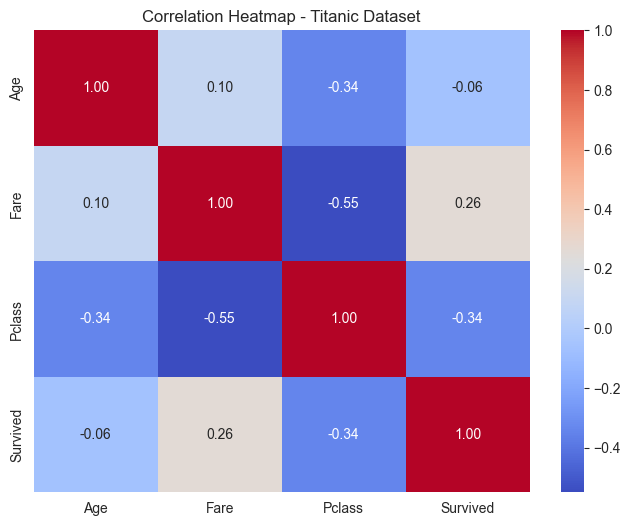

In [22]:
# Titatinic correlation heatmap
plt.figure(figsize=(8,6))

sns.heatmap(
    titanic_corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap - Titanic Dataset")

plt.show()

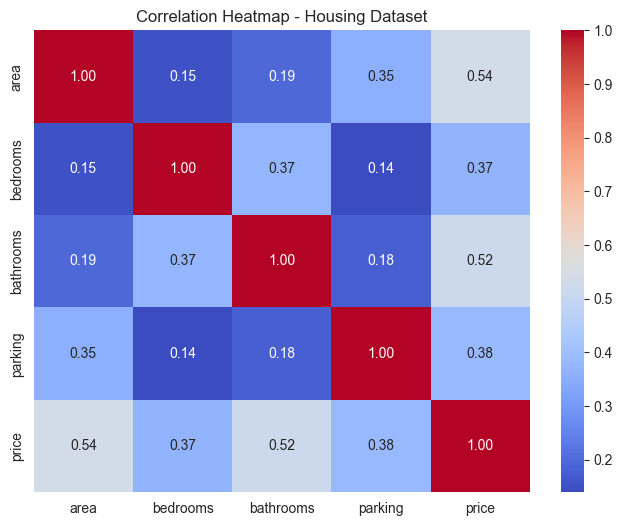

In [23]:
# Housing correlation heatmap

plt.figure(figsize=(8,6))

sns.heatmap(
    housing_corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap - Housing Dataset")

plt.show()